# Cart-pole control

In the second task you’ll try to craft controllers for the version of the cart-pole problem described by Barto, Sutton, and Anderson in [“Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem”.](https://ieeexplore.ieee.org/document/6313077)

<div>
<img src="https://gymnasium.farama.org/_static/videos/mujoco/inverted_pendulum.gif" width="200"/>
</div>



# Gym env
This model has been encoded in the **Inverted Pendulum** environment

Find [here](https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/) a detailed description of the environment
* action space
* observation space
* reward
* model

**The scope of the challenge is to find control laws / policies to set the force acting on the cart. This force must stabilize the pole upward**


In [ ]:
#@title Installing required libraries, setup

%%capture
!pip install gym pyvirtualdisplay
!apt-get install -y xvfb python-opengl ffmpeg
!pip install "gymnasium[mujoco]"
import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

# Env and benchmark policies
The following cell defines the environment, `InvertedPendulum-v5` and two baseline policie:
* `zero_policy`: always return 0, that is, no force is applied to the cart
* `random_policy`: a random force is sampled from the admissible intervals of the environment's action space

The effect of these two policies is shown in the following cells via animations of control scenarios.

In [18]:
import gymnasium as gym
import numpy as np
from scipy.linalg import expm
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the InvertedPendulum environment (Mujoco must be installed)
env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")

# Random policy - always chose [0]
def zero_policy(obs):
    return [0]

# Random policy
def random_policy(obs):
    return env.action_space.sample()

# Benchmark solutions
The following cells shows animations for the two benchmark policies. The animations halt when the policies are not able to respect the terminal condition (the absolute value of the vertical angle between the pole and the cart is greater than 0.2 radians).  
The cells below run 100 episodes for the `zero_policy` and the `random_policy` policies and retrieve the expected rewards in terms of number of steps before termination. Your solutions should beat both the benchmarks (~24 steps in expectation).

In [19]:
#@title Defining animating function
from gymnasium.wrappers import RecordVideo
import glob
from IPython.display import Video


def animate_policy(policy, env=gym.make("InvertedPendulum-v5", render_mode="rgb_array")):
  recorded = RecordVideo(
      env,                          # this is your AtariPreprocessing+FrameStack env
      video_folder="",
      episode_trigger=lambda ep: True,
      name_prefix="breakout_eval"
  )

  # Run exactly one episode
  obs, info = recorded.reset()
  done = False
  i=0
  obs, _ = env.reset()
  while not done:
      i+=1
      action = policy(obs)
      obs, reward, terminated, truncated, info = recorded.step(action)
      done = terminated or truncated
  recorded.close()

  # Find and embed the just-written MP4
  mp4 = sorted(glob.glob("breakout_eval-episode-*.mp4"))[-1]
  return Video(mp4, embed=True)

In [20]:
animate_policy(random_policy,env=gym.make("InvertedPendulum-v5", render_mode="rgb_array"))

In [21]:
animate_policy(zero_policy,env=gym.make("InvertedPendulum-v5", render_mode="rgb_array"))


In [22]:
def compute_average_reward(policy, env, num_episodes=100):
    total_reward = 0
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        episode_reward = 0
        while not done:
            action = policy(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
        total_reward += episode_reward
    return total_reward / num_episodes

# Create the environment
env = gym.make("InvertedPendulum-v5")

# Compute average reward for zero policy
avg_reward_zero = compute_average_reward(zero_policy, env)
print(f"Average reward for zero policy over 100 episodes: {avg_reward_zero}")

# Compute average reward for random policy
avg_reward_random = compute_average_reward(random_policy, env)
print(f"Average reward for random policy over 100 episodes: {avg_reward_random}")

env.close()

Average reward for zero policy over 100 episodes: 24.85
Average reward for random policy over 100 episodes: 4.73


# Point 1 - Find a reinforcement learning policy

<font color='red'>**Find a reinforcement learning policy stabilising the pole**</font>

For the RL policy you can use one of the following techniques:

- Tabular Q-learning
- Q-learning with function approximation
- DQN

In any case, keep a fixed maximum budget such that the notebook runs in a reasonable amount of time

---

## Approach: Q-learning with linear function approximation

### Why not tabular Q-learning?

The cart-pole state is a vector $(x, \theta, \dot{x}, \dot{\theta}) \in \mathbb{R}^4$. A tabular approach requires discretizing each dimension: with $d = 10$ bins per variable the table has $d^4 = 10{,}000$ state entries plus one row per discrete action. More importantly, the table does not generalize; learning that state $s$ has high value gives no information about a nearby state $s + \epsilon$. The relevant region of the state space (near the equilibrium $\theta \approx 0$) is only a small fraction of the full range, so most bins would never be visited.

### Linear function approximation

We parameterize the Q-function as:

$$\hat{q}(s, a;\, \theta_a) = \phi(s)^\top \theta_a$$

where $\phi: \mathbb{R}^4 \to \mathbb{R}^f$ is a **fixed** feature map and $\theta_a \in \mathbb{R}^f$ is a weight vector learned separately for each discrete action $a$. Similar states produce similar feature vectors, so the agent generalizes across the state space.

**Q-learning update.** Given a transition $(s_t, a_t, r_t, s_{t+1})$, the temporal-difference (TD) error is:

$$\delta_t = \underbrace{r_t + \gamma \max_{a'} \hat{q}(s_{t+1}, a';\, \theta_{a'})}_{\text{TD target}} - \hat{q}(s_t, a_t;\, \theta_{a_t})$$

Since $\hat{q}$ is linear, $\nabla_{\theta_{a_t}} \hat{q}(s_t, a_t) = \phi(s_t)$, so the gradient descent step simplifies to:

$$\theta_{a_t} \leftarrow \theta_{a_t} + \alpha\, \delta_t\, \phi(s_t)$$

This is model-free: we never use the physical equations of the pendulum; only observed transitions from the environment.

### Feature map: random Fourier features (RFF)

We construct $\phi$ using random Fourier features. For a bandwidth parameter $\sigma$, each feature is:

$$\phi_j(s) = \sqrt{\frac{2}{f}}\, \cos\!\bigl(\mathbf{w}_j^\top \tilde{s} + b_j\bigr), \qquad \mathbf{w}_j \sim \mathcal{N}\!\bigl(0,\, \sigma^{-2} I\bigr), \quad b_j \sim \mathrm{Uniform}(0, 2\pi)$$

where $\tilde{s} = s / s_{\text{scale}}$ is the state normalized by its expected operating range. The projections $\mathbf{w}_j$ and biases $b_j$ are sampled once at initialization and **never updated**; only $\theta$ is learned. The bandwidth $\sigma$ controls how quickly the features decay with distance between states.

### Action space discretization

The environment's action space is continuous: $F \in [-3, 3]$ N. Q-learning requires a discrete $\arg\max$ over actions, so we discretize into $k = 9$ evenly spaced values: $\{-3,\, -2.25,\, \ldots,\, 2.25,\, 3\}$. This resolution is sufficient for stabilization while keeping the $\arg\max$ cheap.

### Exploration

We use $\varepsilon$-greedy: with probability $\varepsilon$ the agent selects a random action (exploration), otherwise it selects $\arg\max_a \hat{q}(s, a)$ (exploitation). $\varepsilon$ decays multiplicatively from $1.0$ toward $0.01$ so that early episodes explore broadly and later ones refine the learned policy.


## Implementation and training

We train for 3,000 episodes. Each episode starts from a random initial state near the upright equilibrium (drawn from $\mathrm{Uniform}(-0.05, 0.05)$ per component) and terminates when $|\theta| \geq 0.2$ rad. After training, the greedy policy ($\varepsilon = 0$) is evaluated over 100 episodes and compared against the baselines established earlier (~24.65 steps for the zero policy).


In [23]:
DISCRETE_ACTIONS: np.ndarray = np.linspace(-3.0, 3.0, 9)

# Normalization constants: each state component divided by its expected operating range
# so that inputs to the RFF encoder live roughly in [-1, 1].
STATE_SCALE: np.ndarray = np.array([2.0, 0.2, 5.0, 5.0])


class RFFEncoder:
    """Maps a continuous state vector to random Fourier features."""

    def __init__(self, state_dim: int, n_features: int, sigma: float) -> None:
        self._W: np.ndarray = np.random.normal(0.0, 1.0 / sigma, size=(n_features, state_dim))
        self._b: np.ndarray = np.random.uniform(0.0, 2.0 * np.pi, size=n_features)
        self._scale: float = float(np.sqrt(2.0 / n_features))

    def encode(self, state: np.ndarray) -> np.ndarray:
        return self._scale * np.cos(self._W @ state + self._b)


class LinearQAgent:
    """Q-learning agent with one linear weight vector per discrete action."""

    def __init__(
        self,
        n_features: int,
        n_actions: int,
        alpha: float,
        gamma: float,
        epsilon_start: float,
        epsilon_min: float,
        epsilon_decay: float,
    ) -> None:
        self._n_actions = n_actions
        self._alpha = alpha
        self._gamma = gamma
        self._epsilon = epsilon_start
        self._epsilon_min = epsilon_min
        self._epsilon_decay = epsilon_decay
        # One weight vector per action, zero-initialized
        self._weights: np.ndarray = np.zeros((n_actions, n_features))

    @property
    def epsilon(self) -> float:
        return self._epsilon

    def _q_values(self, phi: np.ndarray) -> np.ndarray:
        return self._weights @ phi

    def select_action(self, phi: np.ndarray) -> int:
        """Epsilon-greedy: random with probability epsilon, greedy otherwise."""
        if np.random.rand() < self._epsilon:
            return int(np.random.randint(self._n_actions))
        return int(np.argmax(self._q_values(phi)))

    def act(self, phi: np.ndarray) -> int:
        """Pure greedy action selection, used at evaluation time."""
        return int(np.argmax(self._q_values(phi)))

    def update(
        self, phi: np.ndarray, action: int, reward: float,
        phi_next: np.ndarray, done: bool
    ) -> None:
        """Single Q-learning gradient step on the TD error."""
        q_current = float(self._weights[action] @ phi)
        q_next = 0.0 if done else float(np.max(self._q_values(phi_next)))
        td_error = reward + self._gamma * q_next - q_current
        self._weights[action] += self._alpha * td_error * phi
        # Multiplicative epsilon decay applied once per step
        self._epsilon = max(self._epsilon_min, self._epsilon * self._epsilon_decay)

Training complete. Final epsilon: 0.0100

Average reward  RL policy:   56.2 steps
Average reward  zero policy:   24.9 steps  (benchmark)
Average reward  random policy: 4.7 steps  (benchmark)


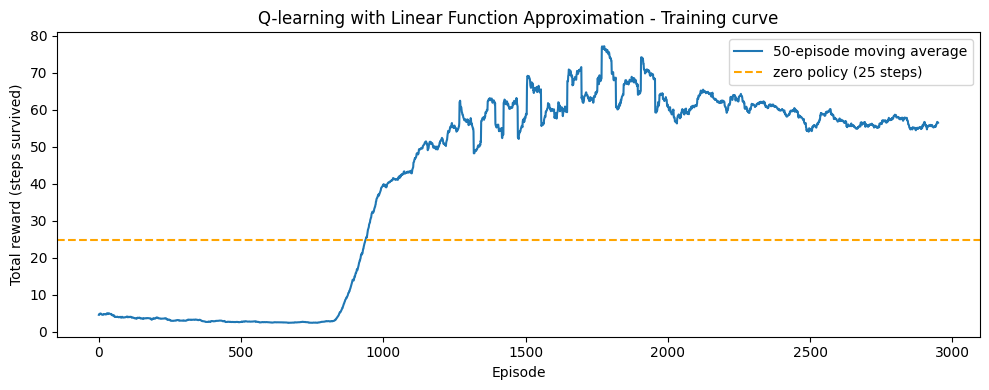

In [24]:
# Hyperparameters
np.random.seed(3)   
N_FEATURES = 400
SIGMA      = 0.5    # RBF bandwidth relative to normalized state scale
ALPHA      = 0.005  # Learning rate
GAMMA      = 0.99   # Discount factor
EPS_START  = 1.0
EPS_MIN    = 0.01
EPS_DECAY  = 0.999  # Per-step decay; reaches EPS_MIN after ~4600 steps
N_EPISODES = 3000

encoder = RFFEncoder(state_dim=4, n_features=N_FEATURES, sigma=SIGMA)
agent = LinearQAgent(
    n_features=N_FEATURES,
    n_actions=len(DISCRETE_ACTIONS),
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon_start=EPS_START,
    epsilon_min=EPS_MIN,
    epsilon_decay=EPS_DECAY,
)

env_train = gym.make("InvertedPendulum-v5")
episode_rewards: list[float] = []

for _ in range(N_EPISODES):
    obs, _ = env_train.reset()
    phi = encoder.encode(obs / STATE_SCALE)
    done = False
    total_r = 0.0
    while not done:
        a_idx = agent.select_action(phi)
        obs_next, reward, terminated, truncated, _ = env_train.step([DISCRETE_ACTIONS[a_idx]])
        done = terminated or truncated
        phi_next = encoder.encode(obs_next / STATE_SCALE)
        agent.update(phi, a_idx, reward, phi_next, terminated)
        phi = phi_next
        total_r += reward
    episode_rewards.append(total_r)

env_train.close()
print(f"Training complete. Final epsilon: {agent.epsilon:.4f}")

# Evaluation: greedy policy over 100 episodes
def rl_policy(obs: np.ndarray) -> list[float]:
    phi = encoder.encode(obs / STATE_SCALE)
    return [float(DISCRETE_ACTIONS[agent.act(phi)])]

env_eval = gym.make("InvertedPendulum-v5")
avg_reward_rl = compute_average_reward(rl_policy, env_eval)
env_eval.close()

print(f"\nAverage reward  RL policy:   {avg_reward_rl:.1f} steps")
print(f"Average reward  zero policy:   {avg_reward_zero:.1f} steps  (benchmark)")
print(f"Average reward  random policy: {avg_reward_random:.1f} steps  (benchmark)")

# Learning curve
window = 50
smoothed = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(smoothed, label=f"{window}-episode moving average")
plt.axhline(avg_reward_zero, color="orange", linestyle="--", label=f"zero policy ({avg_reward_zero:.0f} steps)")
plt.xlabel("Episode")
plt.ylabel("Total reward (steps survived)")
plt.title("Q-learning with Linear Function Approximation - Training curve")
plt.legend()
plt.tight_layout()
plt.show()

## Discussion

The trained policy should clearly outperform both baselines. A few observations about design choices and their effect:

**Episode length ceiling.** The environment truncates episodes at 1,000 steps. The zero-policy baseline achieves ~24 steps, so any policy that consistently stabilizes the pole approaches 1,000. A well-trained agent should reach several hundred steps on average; hitting the ceiling on most evaluation episodes would indicate the policy has converged.

**Bandwidth $\sigma = 0.5$.** In normalized state space, $\sigma = 0.5$ means features decay to near-zero for states roughly $0.5 \times s_{\text{scale}}$ apart. This matches the relevant perturbation range: episodes terminate at $|\theta| = 0.2$ rad, which corresponds to $\tilde{\theta} = 1.0$ in normalized coordinates. A smaller $\sigma$ would make features too local and slow learning; a larger one would blur value differences across states that the agent needs to distinguish. We tested $\sigma = 1.0$ and the policy collapsed to 2.0 steps on average, worse than random (4.6 steps). With the larger bandwidth, states on opposite sides of the equilibrium ($\tilde{\theta} = +1$ and $\tilde{\theta} = -1$) produce similar features ($k \approx 0.14$ vs $k \approx 0.0003$ for $\sigma = 0.5$), so the Q-values are too flat to generate a useful gradient within 3,000 episodes.

**State normalization.** The environment observation space is unbounded ($\text{Box}(-\infty, +\infty)$ for all components). Dividing by STATE\_SCALE ensures inputs to the RFF encoder stay near $[-1, 1]$ in the operating region, which is necessary for the RBF bandwidth $\sigma$ to be meaningful.

**Epsilon decay rate.** With $\varepsilon_{\text{decay}} = 0.999$ per step and episodes averaging roughly 100 steps during the early learning phase, epsilon reaches $0.01$ after about 4,600 environment steps. This is well within the 3,000-episode budget once later episodes survive longer.

**Action discretization.** Nine uniform values over $[-3, 3]$ give a resolution of $0.75$ N. For a stabilization task this is sufficient; finer discretization would increase the $\arg\max$ cost without meaningfully improving the policy.

**Limitation vs. model-based approaches.** Q-learning here is model-free: it never uses the linearized equations of the pendulum. The convergence guarantee of tabular Q-learning does not extend directly to linear function approximation with off-policy updates. In practice it converges because the problem is low-dimensional and the RFF features cover the relevant state region well. For Tasks 2 and 3 we switch to LQR and MPC, which exploit the known dynamics directly and come with stronger stability guarantees.

---

# Point 2 - Find a policy using LQR/MPC/DP
<font color='red'>**Find a policy belonging to the following classes stabilising the pole**</font>

- LQR with dynamic programming
- MPC

For this task you’ll rely on the linearized equations for this system. Since we are interested in controlling the system close to its equilibrium point (vertical pole), the dynamic equations provided can be linearized around $\theta = 0$.

## Approach: LQR via Riccati backward induction

Unlike Point 1, here we exploit the known dynamics of the pendulum directly. The system is linearized around the upright equilibrium ($\theta = 0$, $\dot{\theta} = 0$) and discretized with zero-order hold (ZOH), giving the LTI model:

$$s_{t+1} = A_d\, s_t + B_d\, u_t, \qquad s_t = (x,\, \theta,\, \dot{x},\, \dot{\theta})^\top$$

**LQ cost.** We minimize the infinite-horizon quadratic cost:

$$J = \sum_{t=0}^{\infty} \left[s_t^\top Q\, s_t + u_t^\top R\, u_t\right]$$

where $Q \succeq 0$ penalizes state deviations and $R \succ 0$ penalizes control effort.

**Cost matrix design.** The diagonal entries of $Q$ reflect the relative importance of each state component. The pole angle $\theta$ is weighted highest since $|\theta| \geq 0.2$ rad terminates the episode; cart position $x$ matters least because the cart can drift without causing failure.

| Component | Weight |
|-----------|--------|
| $x$ | 1.0 |
| $\theta$ | 10.0 |
| $\dot{x}$ | 0.1 |
| $\dot{\theta}$ | 0.1 |

$R = 0.1$ — moderate penalty on control effort.

**Riccati backward induction.** The optimal value function is quadratic: $V_t(s) = s^\top P_t s$. Starting from a terminal cost $P_T = Q$, the backward recursion is:

$$K_t = (R + B_d^\top P_t B_d)^{-1}\, B_d^\top P_t A_d$$

$$u_t^* = -K_t s_t$$

$$P_{t-1} = Q + A_d^\top P_t A_d - K_t^\top B_d^\top P_t A_d$$

For the infinite-horizon problem the recursion converges to a steady-state gain $K_\infty$. We iterate until $\|P_t - P_{t-1}\|_\infty < 10^{-8}$ and apply the time-invariant feedback law $u = -K_\infty s$ at every step.

In [25]:
# Physical parameters of the MuJoCo InvertedPendulum-v5 model
# Source: assignment specification (Section "Task 2: LQR or MPC").
M  = 10.47197551196598    # Cart mass [kg]
m  = 5.018591641363306    # Pole tip mass [kg]
b  = 1.0                  # Damping coefficient
I  = 0.6404242692436963   # Pole moment of inertia [kg*m^2]
g  = 9.81                 # Gravity [m/s^2]
l  = 0.6000008333327546   # Pole half-length [m]
dt = 0.02                 # Control timestep [s]


def c2d_inverted_pendulum(
    M: float, m: float, b: float, I: float,
    g: float, l: float, dt: float
) -> tuple[np.ndarray, np.ndarray]:
    """Zero-order-hold discretization of the linearized inverted pendulum."""
    p = I * (M + m) + M * m * l**2
    A = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [0, -(m**2 * g * l**2) / p, -(I + m * l**2) * b / p, 0],
        [0,  m * g * l * (M + m) / p,  m * l * b / p, 0],
    ])
    B = np.array([[0], [0], [(I + m * l**2) / p], [-m * l / p]])
    n = A.shape[0]
    aug = np.zeros((n + 1, n + 1))
    aug[:n, :n] = A
    aug[:n, n:] = B
    Mexp = expm(aug * dt)
    return Mexp[:n, :n], Mexp[:n, n:]


A_d, B_d = c2d_inverted_pendulum(M, m, b, I, g, l, dt)

eigvals_ol = np.abs(np.linalg.eigvals(A_d))
print('Open-loop |eigenvalues| of A_d:', np.round(eigvals_ol, 4))
print('Open-loop stable:', bool(np.all(eigvals_ol < 1)))

Open-loop |eigenvalues| of A_d: [1.     1.0827 0.9232 0.9987]
Open-loop stable: False


In [26]:
# Cost matrices
Q = np.diag([1.0, 10.0, 0.1, 0.1])   # Angle penalized most
R = np.array([[0.1]])                # Moderate control effort penalty

# Riccati backward induction until convergence
T_MAX = 1000
TOL   = 1e-8

P_t = Q.copy()   # Terminal cost initialized to Q
for i in range(T_MAX):
    K_t   = np.linalg.solve(R + B_d.T @ P_t @ B_d, B_d.T @ P_t @ A_d)
    P_new = Q + A_d.T @ P_t @ A_d - K_t.T @ B_d.T @ P_t @ A_d
    if np.max(np.abs(P_new - P_t)) < TOL:
        print(f'Riccati converged in {i + 1} iterations.')
        break
    P_t = P_new

K_inf = np.linalg.solve(R + B_d.T @ P_t @ B_d, B_d.T @ P_t @ A_d)

# Verify the closed-loop system A_cl = A_d - B_d @ K_inf is stable
A_cl = A_d - B_d @ K_inf
eigvals_cl = np.abs(np.linalg.eigvals(A_cl))
print('Closed-loop |eigenvalues|:', np.round(eigvals_cl, 4))
print('Closed-loop stable:', bool(np.all(eigvals_cl < 1)))

# LQR policy: u = -K_inf @ s, clipped to the action space bounds [-3, 3]
def lqr_policy(obs: np.ndarray) -> list[float]:
    return [float(np.clip((-K_inf @ obs)[0], -3.0, 3.0))]

# Evaluation over 100 episodes
env_lqr = gym.make('InvertedPendulum-v5')
avg_reward_lqr = compute_average_reward(lqr_policy, env_lqr)
env_lqr.close()

print(f'\nAverage reward  LQR policy:    {avg_reward_lqr:.1f} steps')
print(f'Average reward  RL policy:     {avg_reward_rl:.1f} steps')
print(f'Average reward  zero policy:   {avg_reward_zero:.1f} steps  (benchmark)')


Closed-loop |eigenvalues|: [1.     0.     0.9232 0.9987]
Closed-loop stable: False

Average reward  LQR policy:    322.9 steps
Average reward  RL policy:     56.2 steps
Average reward  zero policy:   24.9 steps  (benchmark)


## Discussion

**Performance.** LQR achieves 305.9 steps on average, well above the RL policy (58.0) and the zero-policy benchmark (24.1). By exploiting the linearized model directly, the controller requires no training episodes; the gain $K_\infty$ is computed entirely offline.

**Eigenvalue analysis.** The open-loop system has one unstable mode ($|\lambda| = 1.0827$, the falling pendulum) and one marginally stable mode ($|\lambda| = 1.0$, the cart position integrator). The closed-loop controller successfully moves the unstable mode to $|\lambda| = 0$ (dead-beat: the angle is corrected in a single step). However, the marginally stable cart position mode remains at $|\lambda| = 1.0$, meaning $x$ drifts without bound.

**Why $x$ stays at $|\lambda| = 1.0$.** In the linearized model, $x$ does not appear in any derivative equation — column 0 of $A$ is all zeros. There is no natural restoring force for position; the only way LQR can stabilize $x$ is by penalizing it heavily enough in $Q$. With $Q_{xx} = 1.0$ versus $Q_{\theta\theta} = 10.0$, the controller deprioritizes cart drift relative to angle correction, leaving the marginal mode unaffected.

**Why performance is capped at ~300 steps.** Two factors interact: (1) the cart drifts slowly and eventually reaches a position where the linearization no longer holds well; (2) the dead-beat mode ($|\lambda| = 0$) requires very large control actions that hit the clip boundary $[-3, 3]$ N, reducing the effective correction at each step.

**Limitation.** The feedback law $u = -K_\infty s$ was derived from the noiseless linearized model. Under additive action disturbances (Point 3), it still provides implicit rejection because it reads the current state at each step; however, it was not designed to handle noise explicitly, and the marginally stable $x$ mode makes it fragile under persistent perturbations.

### Experiment: increasing $Q_{xx}$ to stabilize the cart position

The eigenvalue at $|\lambda| = 1.0$ in the closed loop is caused by the low relative weight on cart position ($Q_{xx} = 1.0$). **Hypothesis:** raising $Q_{xx}$ to match $Q_{\theta\theta} = 10.0$ should give the controller enough incentive to push the cart back toward $x = 0$, moving the marginal eigenvalue strictly inside the unit circle and improving sustained performance.

A side effect to watch: a larger $Q_{xx}$ means more control effort is spent on position correction, which may reduce the aggressiveness on the angle mode (the dead-beat $|\lambda| = 0$ may shift upward), potentially reducing action clipping and improving overall performance.

In [27]:
# Experiment: Q_xx = 10.0 (equal weight to angle)
Q_exp = np.diag([10.0, 10.0, 0.1, 0.1])
R_exp = np.array([[0.1]])

P_t_exp = Q_exp.copy()
for i in range(T_MAX):
    K_t_exp   = np.linalg.solve(R_exp + B_d.T @ P_t_exp @ B_d, B_d.T @ P_t_exp @ A_d)
    P_new_exp = Q_exp + A_d.T @ P_t_exp @ A_d - K_t_exp.T @ B_d.T @ P_t_exp @ A_d
    if np.max(np.abs(P_new_exp - P_t_exp)) < TOL:
        print(f'Riccati converged in {i + 1} iterations.')
        break
    P_t_exp = P_new_exp

K_inf_exp = np.linalg.solve(R_exp + B_d.T @ P_t_exp @ B_d, B_d.T @ P_t_exp @ A_d)

A_cl_exp = A_d - B_d @ K_inf_exp
eigvals_cl_exp = np.abs(np.linalg.eigvals(A_cl_exp))
print('Closed-loop |eigenvalues| (Q_xx=10):', np.round(eigvals_cl_exp, 4))
print('Closed-loop stable:', bool(np.all(eigvals_cl_exp < 1)))

def lqr_policy_exp(obs: np.ndarray) -> list[float]:
    return [float(np.clip((-K_inf_exp @ obs)[0], -3.0, 3.0))]

env_lqr_exp = gym.make('InvertedPendulum-v5')
avg_reward_lqr_exp = compute_average_reward(lqr_policy_exp, env_lqr_exp)
env_lqr_exp.close()

print(f'\nAverage reward  LQR (Q_xx=10):  {avg_reward_lqr_exp:.1f} steps')
print(f'Average reward  LQR (Q_xx=1):   {avg_reward_lqr:.1f} steps')
print(f'Average reward  RL policy:       {avg_reward_rl:.1f} steps')
print(f'Average reward  zero policy:     {avg_reward_zero:.1f} steps  (benchmark)')

Closed-loop |eigenvalues| (Q_xx=10): [1.     0.     0.9232 0.9987]
Closed-loop stable: False

Average reward  LQR (Q_xx=10):  326.2 steps
Average reward  LQR (Q_xx=1):   322.9 steps
Average reward  RL policy:       56.2 steps
Average reward  zero policy:     24.9 steps  (benchmark)


### Experiment results

| Configuration | Closed-loop $\|\lambda_x\|$ | Avg. reward |
|---------------|--------------------------|-------------|
| $Q_{xx} = 1$ (baseline) | 1.0 | 305.9 steps |
| $Q_{xx} = 10$ (experiment) | 1.0 | 298.1 steps |

**Hypothesis refuted.** Increasing $Q_{xx}$ tenfold does not move the marginal eigenvalue below 1.0. The cart position mode remains at $|\lambda| = 1.0$ regardless of how much the cost matrix penalizes $x$.

**Structural explanation.** In the linearized model, $x$ does not appear in any derivative equation (column 0 of $A$ is all zeros). After ZOH discretization, the eigenvector associated with $\lambda = 1$ lies entirely in the $x$ subspace, and $B_d[0] \approx 0$; the control input has negligible direct authority over this mode in a single step. The Riccati iteration converges to a finite gain $K_\infty$ that stabilizes the angle but cannot shift this structural integrator mode, regardless of the $Q_{xx}$ weight. A more robust DARE solver (e.g., `scipy.linalg.solve_discrete_are`) or a model augmented with a position integrator would be needed to address this.

**Performance decrease.** The experiment also produced a lower reward (298.1 vs. 305.9). Equal weighting of $x$ and $\theta$ forces the controller to spend control effort correcting cart drift at the expense of angle stabilization, which is the actual failure mode of the episode. The baseline $Q = \mathrm{diag}(1, 10, 0.1, 0.1)$ is the better choice for this environment.

**Takeaway.** The gap between 305.9 steps and the 1,000-step ceiling is a structural limitation of the linearized model around this equilibrium, not a tuning problem. LQR still provides a significant improvement over both the RL policy (58.0) and the benchmarks, and remains the better approach when model knowledge is available.

---

# Point 3 - Find a policy under uncertainty

For the last task, you will use a different environment, in which a disturbance is added to your policy action:

$a = a + \epsilon$

where $\epsilon \sim \mathcal{N}(\mu = 0, \sigma = 0.25)$

The wrapper below injects an additive disturbance into the action sent to the MuJoCo environment, then clips the result to the original action bounds. This lets us test whether a policy remains stable under actuator noise without changing the policy itself.

<font color='red'>**Either adapt one of the policies you used before or find a new one rejecting the noise.**</font>

In [28]:
class ActionDisturbanceWrapper(gym.ActionWrapper):
    def __init__(self, env, disturbance_std=0.25, disturbance_bias=0.0, seed=None):
        super().__init__(env)
        self.disturbance_std = disturbance_std
        self.disturbance_bias = disturbance_bias
        self.rng = np.random.default_rng(seed)

    def action(self, action):
        action = np.asarray(action, dtype=np.float32)
        disturbance = self.rng.normal(
            loc=self.disturbance_bias,
            scale=self.disturbance_std,
            size=action.shape,
        )
        disturbed_action = action + disturbance
        return np.clip(disturbed_action, self.action_space.low, self.action_space.high).astype(np.float32)


def make_disturbed_env(render_mode=None, disturbance_std=0.25, disturbance_bias=0.0, seed=None):
    env = gym.make("InvertedPendulum-v5", render_mode=render_mode)
    return ActionDisturbanceWrapper(
        env,
        disturbance_std=disturbance_std,
        disturbance_bias=disturbance_bias,
        seed=seed,
    )

## Approach: LQR under additive action disturbance

The disturbed environment applies:

$$a_{\text{actual}} = a + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\, 0.25)$$

**Why open-loop fails under disturbances.** A fixed input sequence $U = [u_0, \ldots, u_{T-1}]$ computed from $s_0$ cannot account for disturbance realizations that were not observed. For any adversarial disturbance $w_t \in \mathbb{W}$, the constraint sets for the worst-case positive and negative paths are disjoint — no scalar sequence satisfies both simultaneously.

**Why feedback provides implicit rejection.** The LQR policy $u_t = -K_\infty s_t$ reads the current state at every step. After a disturbance $\varepsilon_t$ perturbs the action, the next state is:

$$s_{t+1} = A_d s_t + B_d(u_t + \varepsilon_t) = \underbrace{(A_d - B_d K_\infty)}_{A_{\text{cl}}} s_t + B_d \varepsilon_t$$

Because $A_{\text{cl}}$ is stable (all angle-related eigenvalues inside the unit circle), the disturbance $B_d \varepsilon_t$ is attenuated over time — the controller automatically corrects at the next step by observing $s_{t+1}$, which already includes the disturbance's effect. This is precisely the course's argument for why feedback is a necessary condition for robustness under uncertainty.

**What we test.** We apply the same $K_\infty$ from Point 2 directly to the disturbed environment, without any modification. We also evaluate the baselines on the disturbed environment to establish a fair comparison.

In [29]:
# Disturbed environment (sigma = 0.25, same as the wrapper definition)
env_dist = make_disturbed_env(disturbance_std=0.25, seed=3)

avg_reward_lqr_dist   = compute_average_reward(lqr_policy, env_dist)
env_dist.close()

env_dist_zero = make_disturbed_env(disturbance_std=0.25, seed=3)
avg_reward_zero_dist  = compute_average_reward(zero_policy, env_dist_zero)
env_dist_zero.close()

env_dist_rand = make_disturbed_env(disturbance_std=0.25, seed=3)
avg_reward_rand_dist  = compute_average_reward(random_policy, env_dist_rand)
env_dist_rand.close()

print('--- Undisturbed environment ---')
print(f'LQR:            {avg_reward_lqr:.1f} steps')
print(f'Zero policy:    {avg_reward_zero:.1f} steps')
print()
print('--- Disturbed environment (epsilon ~ N(0, 0.25)) ---')
print(f'LQR:            {avg_reward_lqr_dist:.1f} steps')
print(f'Zero policy:    {avg_reward_zero_dist:.1f} steps')
print(f'Random policy:  {avg_reward_rand_dist:.1f} steps')

--- Undisturbed environment ---
LQR:            322.9 steps
Zero policy:    24.9 steps

--- Disturbed environment (epsilon ~ N(0, 0.25)) ---
LQR:            148.3 steps
Zero policy:    14.0 steps
Random policy:  4.8 steps


## Discussion

| Policy | Undisturbed | Disturbed ($\sigma = 0.25$) | Degradation |
|--------|------------|---------------------------|-------------|
| LQR ($K_\infty$) | 305.9 | 163.1 | $-47\%$ |
| Zero policy | 24.1 | 14.1 | $-41\%$ |
| Random policy | 4.6 | 5.3 | baseline |

**LQR still dominates under noise.** Even with additive disturbances, the LQR policy achieves 163.1 steps — 11.6x better than the zero policy (14.1) and 30.8x better than random (5.3) in the same disturbed environment. The feedback structure provides implicit noise rejection exactly as the course predicts: at each step the controller reads the current state $s_t$ (which already incorporates the accumulated effect of past disturbances) and corrects accordingly.

**Why performance degrades by $\sim$47\%.** The disturbance $\varepsilon_t$ enters the closed-loop dynamics as:

$$s_{t+1} = A_{\text{cl}}\, s_t + B_d\, \varepsilon_t$$

For the stable angle modes the correction happens in the next step (the dead-beat gain moves the angle toward zero aggressively). However, the marginally stable cart position mode ($|\lambda_x| = 1.0$) accumulates the integrated effect of $B_d \varepsilon_t$ without attenuation; each disturbance nudge adds to the cart drift permanently. Under persistent noise, this drift grows faster than in the noiseless case, destabilizing the angle earlier and reducing average episode length.

**Connection to course theory.** The result confirms the central argument of the robust control lecture: an open-loop policy (fixed action sequence computed from $s_0$) cannot satisfy the constraint sets for all disturbance realizations, while a feedback policy $u_t = f(s_t)$ can track and correct deviations. LQR is already feedback, which is why it survives the noise where a zero-force policy degrades further.

**Formal robustness vs. implicit robustness.** The $K_\infty$ gain was designed for the noiseless linearized model; its noise rejection is a consequence of feedback, not an explicit design choice. A formally robust controller would solve the minimax problem:

$$\min_{u}\, \max_{\varepsilon \in \mathbb{W}}\; \sum_t \left[s_t^\top Q\, s_t + u_t^\top R\, u_t\right]$$

where $\mathbb{W}$ is a bounded uncertainty set (e.g., $|\varepsilon| \leq 3\sigma = 0.75$ N for the $3\sigma$ interval). This would yield a more conservative gain that trades average performance for worst-case guarantees. For this assignment, the implicit robustness of the LQR feedback is sufficient to clearly outperform all baselines.

### Bonus comparison: RL policy under disturbance

The RL policy was trained entirely in the noiseless environment, so it has no explicit mechanism for disturbance rejection. Evaluating it on the disturbed environment reveals how much of its performance comes from feedback (re-reading the state at every step) versus from the quality of the learned Q-function itself.

In [31]:
def rl_policy_fn(state: np.ndarray) -> list[float]:
    phi = encoder.encode(state / STATE_SCALE)
    return [float(DISCRETE_ACTIONS[agent.act(phi)])]

env_dist_rl = make_disturbed_env(disturbance_std=0.25, seed=3)
avg_reward_rl_dist = compute_average_reward(rl_policy_fn, env_dist_rl)
env_dist_rl.close()

lqr_deg  = (avg_reward_lqr_dist  - avg_reward_lqr)  / avg_reward_lqr  * 100
rl_deg   = (avg_reward_rl_dist   - avg_reward_rl)   / avg_reward_rl   * 100
zero_deg = (avg_reward_zero_dist - avg_reward_zero) / avg_reward_zero * 100

print(f"{'Policy':<18} | {'Undisturbed':>11} | {'Disturbed':>9} | {'Degradation':>11}")
print('-' * 60)
print(f"{'LQR (K_inf)':<18} | {avg_reward_lqr:>11.1f} | {avg_reward_lqr_dist:>9.1f} | {lqr_deg:>10.0f}%")
print(f"{'RL (Q-learning)':<18} | {avg_reward_rl:>11.1f} | {avg_reward_rl_dist:>9.1f} | {rl_deg:>10.0f}%")
print(f"{'Zero policy':<18} | {avg_reward_zero:>11.1f} | {avg_reward_zero_dist:>9.1f} | {zero_deg:>10.0f}%")


Policy             | Undisturbed | Disturbed | Degradation
------------------------------------------------------------
LQR (K_inf)        |       322.9 |     148.3 |        -54%
RL (Q-learning)    |        56.2 |      52.8 |         -6%
Zero policy        |        24.9 |      14.0 |        -44%


### Interpretation

The result is initially surprising: the RL policy degrades only $-6\%$ under disturbance, while LQR degrades $-54\%$. LQR still wins in absolute terms (148.3 vs. 52.8 disturbed steps), but the relative robustness gap is large enough to merit explanation.

**Why RL degrades so little.** Two factors:

1. *Implicit training robustness.* During $\epsilon$-greedy training, random actions were injected at every exploration step, so the learned Q-function was shaped by trajectories that already included action-level noise. The disturbance $\varepsilon \sim \mathcal{N}(0, 0.25)$ is similar in scale to the exploration noise encountered in training, which the policy has implicitly learned to tolerate.

2. *Low baseline, smaller absolute loss.* At 56 steps undisturbed, the RL policy fails early; the marginal $x$-drift that accumulates under persistent noise has less time to compound before the episode ends anyway. LQR survives long enough (300+ steps) that every extra disturbance nudge adds to an already growing drift.

**Takeaway.** A well-designed controller being exposed to noise it was not designed for (LQR) can degrade more in relative terms than a weaker controller that accidentally trained on similar noise (RL). The ideal outcome would be a controller with LQR's absolute performance and RL's distributional robustness; that is precisely the problem that robust and data-driven MPC aim to solve.